1、不同的文档，使用不同的文档加载器 （熟悉）

txt文档：TextLoader

pdf文档：PyPDFLoader

csv文档：CSVLoader

json文档：JSONLoader

html文档：UnstructuredHTMLLoader

md文档：UnStructuredMarkdownLoader

文件目录：DirectoryLoader


2、创建好XxxLoader的实例以后，都需要调用load()，在内存中返回一个list[Document]







# 1、加载Txt文档



In [1]:
from langchain_community.document_loaders import TextLoader, PyPDFLoader

# 指明txt文档的路径
file_path = "./asset/load/01-langchain-utf-8.txt"

# 创建一个TextLoader的实例
text_loader = TextLoader(
    file_path=file_path,
    encoding="utf-8",
)

# 调用load()，返回一个list[Document]
docs = text_loader.load()


In [2]:
print(docs)

print(len(docs))  # 查看列表中元素的个数‘

print(docs[0])

[Document(page_content='LangChain 是一个用于构建基于大语言模型（LLM）应用的开发框架，旨在帮助开发者更高效地集成、管理和增强大语言模型的能力，构建端到端的应用程序。它提供了一套模块化工具和接口，支持从简单的文本生成到复杂的多步骤推理任务', metadata={'source': './asset/load/01-langchain-utf-8.txt'})]
1
Document(page_content='LangChain 是一个用于构建基于大语言模型（LLM）应用的开发框架，旨在帮助开发者更高效地集成、管理和增强大语言模型的能力，构建端到端的应用程序。它提供了一套模块化工具和接口，支持从简单的文本生成到复杂的多步骤推理任务', metadata={'source': './asset/load/01-langchain-utf-8.txt'})


In [3]:
# 显示Document对象的元数据
print(docs[0].metadata)

# 显示文档中的内容信息
print(docs[0].page_content)

{'source': './asset/load/01-langchain-utf-8.txt'}
LangChain 是一个用于构建基于大语言模型（LLM）应用的开发框架，旨在帮助开发者更高效地集成、管理和增强大语言模型的能力，构建端到端的应用程序。它提供了一套模块化工具和接口，支持从简单的文本生成到复杂的多步骤推理任务


In [4]:
from langchain_community.document_loaders import TextLoader

# 指明txt文档的路径
file_path = "./asset/load/01-langchain-gbk.txt"

# 创建一个TextLoader的实例
text_loader = TextLoader(
    file_path=file_path,
    encoding="gbk",  #此时使用的解码集一定要与当初存储此文件使用的编码集相同，否则报错！
)

# 调用load()，返回一个list[Document]
docs = text_loader.load()

print(docs)


[Document(page_content='LangChain 是一个用于构建基于大语言模型（LLM）应用的开发框架，旨在帮助开发者更高效地集成、管理和增强大语言模型的能力，构建端到端的应用程序。它提供了一套模块化工具和接口，支持从简单的文本生成到复杂的多步骤推理任务', metadata={'source': './asset/load/01-langchain-gbk.txt'})]


# 2、加载pdf文档


In [5]:
from langchain_community.document_loaders.pdf import PyPDFLoader

pdf_loader = PyPDFLoader(
    file_path="./asset/load/02-load.pdf"
)

docs = pdf_loader.load()

print(docs)

print(len(docs))

[Document(page_content='PDF loader unavailable for ./asset/load/02-load.pdf', metadata={'source': './asset/load/02-load.pdf'})]
1


也可以加载网络中的一个文件：

In [6]:
from langchain_community.document_loaders.pdf import PyPDFLoader

pdf_loader = PyPDFLoader(
    file_path="https://arxiv.org/pdf/2302.03803"
)

docs = pdf_loader.load()

print(len(docs))

for doc in docs:
    print(doc)

1
Document(page_content='PDF loader unavailable for https://arxiv.org/pdf/2302.03803', metadata={'source': 'https://arxiv.org/pdf/2302.03803'})


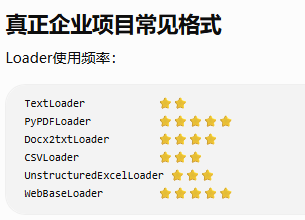

# 3、加载CSV文档

In [7]:
from langchain_community.document_loaders import CSVLoader

csv_loader = CSVLoader(
    file_path="./asset/load/03-load.csv"
)

docs = csv_loader.load()

print(len(docs))


print(docs)

for doc in docs:
    print(doc)

4
[Document(page_content='{"id": "1", "title": "Introduction to Python", "content": "Python is a popular programming language.", "author": "John Doe"}', metadata={'row': 0, 'source': './asset/load/03-load.csv'}), Document(page_content='{"id": "2", "title": "Data Science Basics", "content": "Data science involves statistics and machine learning.", "author": "Jane Smith"}', metadata={'row': 1, 'source': './asset/load/03-load.csv'}), Document(page_content='{"id": "3", "title": "Web Development", "content": "HTML, CSS and JavaScript are core web technologies.", "author": "Mike Johnson"}', metadata={'row': 2, 'source': './asset/load/03-load.csv'}), Document(page_content='{"id": "4", "title": "Artificial Intelligence", "content": "AI is transforming many industries.", "author": "Sarah Williams"}', metadata={'row': 3, 'source': './asset/load/03-load.csv'})]
Document(page_content='{"id": "1", "title": "Introduction to Python", "content": "Python is a popular programming language.", "author": "

In [8]:
from langchain_community.document_loaders import CSVLoader

csv_loader = CSVLoader(
    file_path="./asset/load/03-load.csv",
    source_column="author"
)

docs = csv_loader.load()

for doc in docs:
    print(doc)

Document(page_content='{"id": "1", "title": "Introduction to Python", "content": "Python is a popular programming language.", "author": "John Doe"}', metadata={'row': 0, 'source': './asset/load/03-load.csv', 'source_value': 'John Doe'})
Document(page_content='{"id": "2", "title": "Data Science Basics", "content": "Data science involves statistics and machine learning.", "author": "Jane Smith"}', metadata={'row': 1, 'source': './asset/load/03-load.csv', 'source_value': 'Jane Smith'})
Document(page_content='{"id": "3", "title": "Web Development", "content": "HTML, CSS and JavaScript are core web technologies.", "author": "Mike Johnson"}', metadata={'row': 2, 'source': './asset/load/03-load.csv', 'source_value': 'Mike Johnson'})
Document(page_content='{"id": "4", "title": "Artificial Intelligence", "content": "AI is transforming many industries.", "author": "Sarah Williams"}', metadata={'row': 3, 'source': './asset/load/03-load.csv', 'source_value': 'Sarah Williams'})


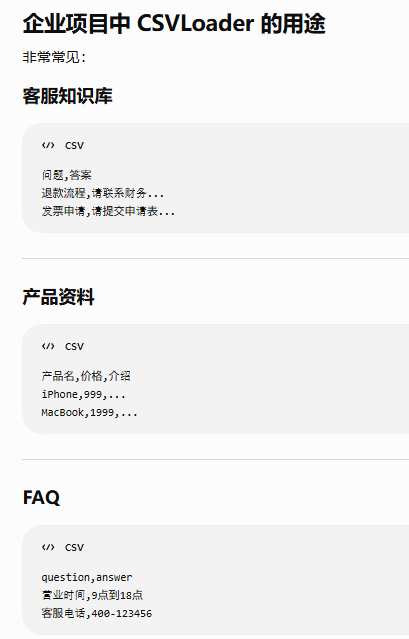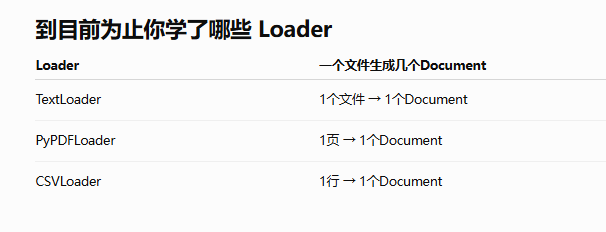

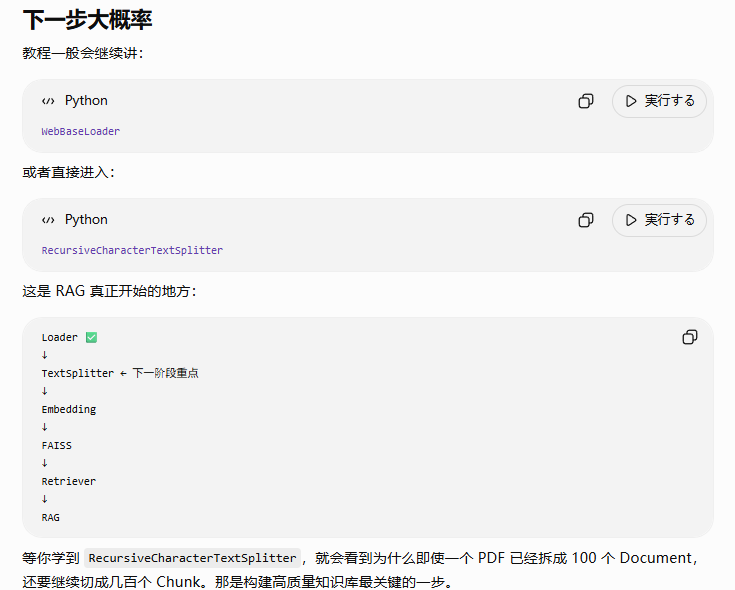

# 4、加载JSON文档

举例1：加载json文件中的所有的数据

In [9]:
from langchain_community.document_loaders import JSONLoader

json_loader = JSONLoader(
    file_path="./asset/load/04-load.json",
    jq_schema=".", #表示加载所有的字段
    text_content=False, #将加载的json对象转换为json字符串
)

docs = json_loader.load()

print(docs)

[Document(page_content='{"messages": [{"sender": "Alice", "content": "Hello, how are you today?", "timestamp": "2023-05-15T10:00:00"}, {"sender": "Bob", "content": "I\'m doing well, thanks for asking!", "timestamp": "2023-05-15T10:02:00"}, {"sender": "Alice", "content": "Would you like to meet for lunch?", "timestamp": "2023-05-15T10:05:00"}, {"sender": "Bob", "content": "Sure, that sounds great!", "timestamp": "2023-05-15T10:07:00"}], "conversation_id": "conv_12345", "participants": ["Alice", "Bob"]}', metadata={'source': './asset/load/04-load.json'})]


举例2：加载json文件中messages[]中的所有的content字段

In [10]:
from langchain_community.document_loaders import JSONLoader

json_loader = JSONLoader(
    file_path="./asset/load/04-load.json",
    jq_schema=".messages[].content", #加载messages[]的所有的content字段
    #text_content=False, #将加载的json对象转换为json字符串
)

docs = json_loader.load()

for doc in docs:
    print(doc.page_content)

{"messages": [{"sender": "Alice", "content": "Hello, how are you today?", "timestamp": "2023-05-15T10:00:00"}, {"sender": "Bob", "content": "I'm doing well, thanks for asking!", "timestamp": "2023-05-15T10:02:00"}, {"sender": "Alice", "content": "Would you like to meet for lunch?", "timestamp": "2023-05-15T10:05:00"}, {"sender": "Bob", "content": "Sure, that sounds great!", "timestamp": "2023-05-15T10:07:00"}], "conversation_id": "conv_12345", "participants": ["Alice", "Bob"]}


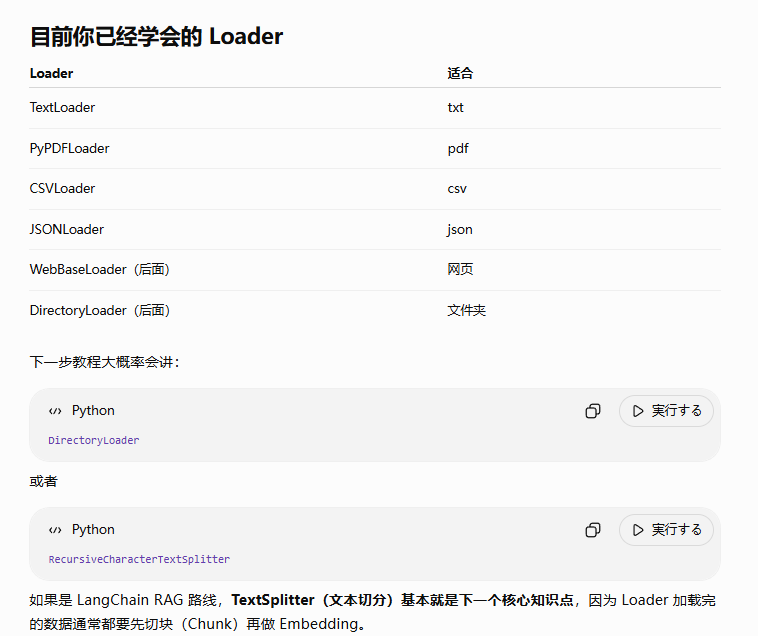

举例3：提取04-response.json文件中嵌套在 data.items[].content 的文本

In [11]:
from langchain_community.document_loaders import JSONLoader

# 方式1：
# json_loader = JSONLoader(
#     file_path="./asset/load/04-response.json",
#     jq_schema=".data.items[].content", #data.items[].content
# )

# 方式2：
json_loader = JSONLoader(
    file_path="./asset/load/04-response.json",
    jq_schema=".data.items[]", #data.items[].content
    content_key=".content",
    is_content_key_jq_parsable=True, #用jq解析content_key
)

docs = json_loader.load()

for doc in docs:
    print(doc.page_content)

{"status": "success", "data": {"page": 2, "per_page": 3, "total_pages": 5, "total_items": 14, "items": [{"id": 101, "title": "Understanding JSONLoader", "content": "This article explains how to parse API responses...", "author": {"id": "user_1", "name": "Alice"}, "created_at": "2023-10-05T08:12:33Z"}, {"id": 102, "title": "Advanced jq Schema Patterns", "content": "Learn to handle nested structures with...", "author": {"id": "user_2", "name": "Bob"}, "created_at": "2023-10-05T09:15:21Z"}, {"id": 103, "title": "LangChain Metadata Handling", "content": "Best practices for preserving metadata...", "author": {"id": "user_3", "name": "Charlie"}, "created_at": "2023-10-05T10:03:47Z"}]}}


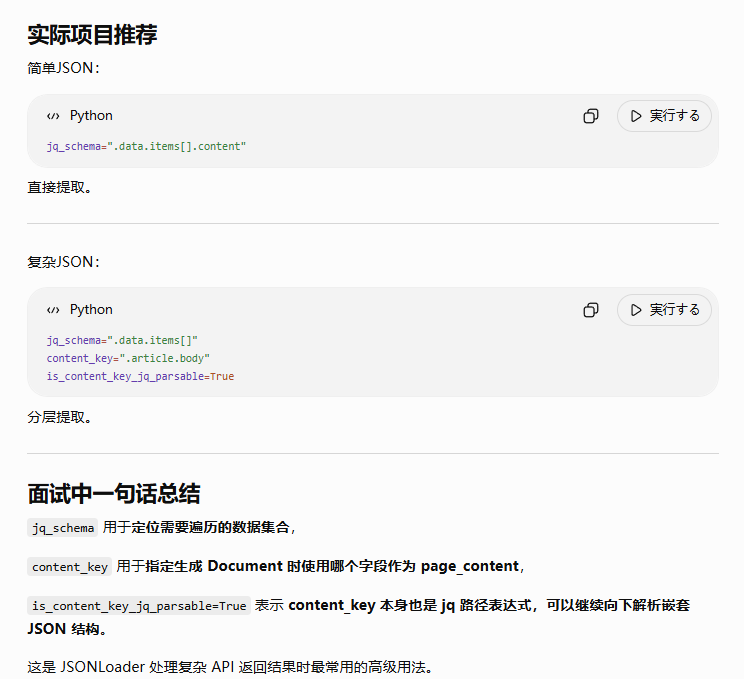

举例4：提取04-response.json文件中嵌套在 data.items[] 里的 title、content 和 其文本



In [14]:
# 1.导入相关依赖
from langchain_community.document_loaders import JSONLoader
from pprint import pprint

# 2.定义json文件的路径
file_path = 'asset/load/04-response.json'

# 3.定义JSONLoader对象
# 提取嵌套在 data.items[].content 的文本，并保留其他字段作为元数据
# loader = JSONLoader(
#     file_path=file_path,
#     # jq_schema=".data.items[] | {id, author, text: (.title + '\n' + .content)}",
#     jq_schema='''.data.items[] | {
#     id,
#     author,
#     created_at,
#     title, # 保留title字段
#     text: (.title + "\n" + .content)
#     }''',
#     content_key=".text",  # 再从条目中提取 content 字段
#     is_content_key_jq_parsable=True  # 用jq解析content_key
# )
loader = JSONLoader(
    file_path=file_path,
    # jq_schema=".data.items[] | {id, author, text: (.title + '\n' + .content)}",
    jq_schema=".data.items[]",
    content_key='.title + "\\n\\n" + .content',
    is_content_key_jq_parsable=True  # 用jq解析content_key
)

# loader = JSONLoader(
#     file_path=file_path,
#     # jq_schema=".data.items[] | {id, author, text: (.title + '\n' + .content)}",
#     jq_schema='''
#         .data.items[] | {
#             metadata: {
#                 id,
#                 author,
#                 created_at
#             },
#             content: (.title + "\n\n" + .content)
#         }
#     ''',  # 构建新结构
#      content_key='.title + "\\n\\n" + .content',
#     is_content_key_jq_parsable=True  # 用jq解析content_key
# )

# 4.加载
data = loader.load()

for doc in data:
    print(doc.page_content)

{"status": "success", "data": {"page": 2, "per_page": 3, "total_pages": 5, "total_items": 14, "items": [{"id": 101, "title": "Understanding JSONLoader", "content": "This article explains how to parse API responses...", "author": {"id": "user_1", "name": "Alice"}, "created_at": "2023-10-05T08:12:33Z"}, {"id": 102, "title": "Advanced jq Schema Patterns", "content": "Learn to handle nested structures with...", "author": {"id": "user_2", "name": "Bob"}, "created_at": "2023-10-05T09:15:21Z"}, {"id": 103, "title": "LangChain Metadata Handling", "content": "Best practices for preserving metadata...", "author": {"id": "user_3", "name": "Charlie"}, "created_at": "2023-10-05T10:03:47Z"}]}}


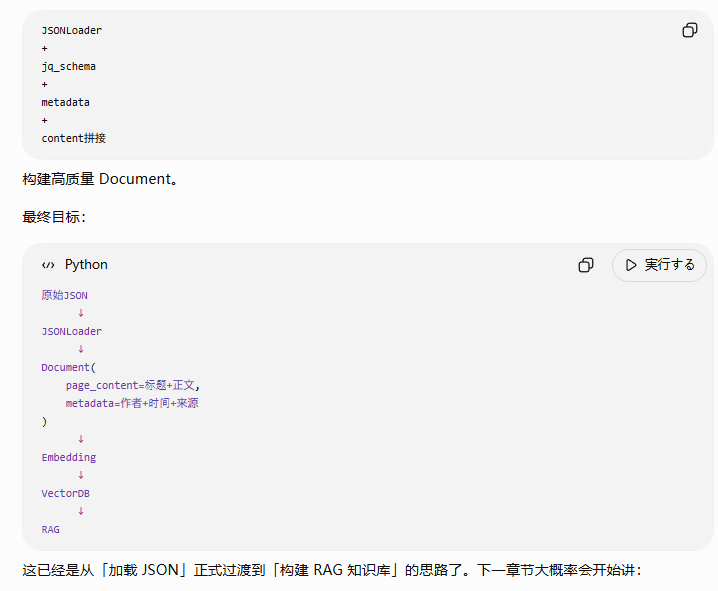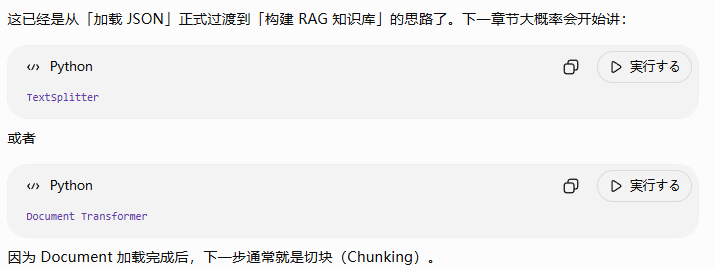

# 5、加载HTML文档

In [16]:
# 1.导入相关的依赖
from langchain.document_loaders import UnstructuredHTMLLoader

# 2.定义UnstructuredHTMLLoader对象
# strategy:
#   "fast" 解析加载html文件速度是比较快（但可能丢失部分结构或元数据）
#   "hi_res": (高分辨率解析) 解析精准（速度慢一些）
#   "ocr_only"  强制使用ocr提取文本，仅仅适用于图像（对HTML无效）

# mode ：one of `{'paged', 'elements', 'single'}
#    "elements"  按语义元素（标题、段落、列表、表格等）拆分成多个独立的小文档

html_loader = UnstructuredHTMLLoader(
    file_path="asset/load/05-load.html",
    mode="elements",
    strategy="fast"
)

# 3.加载
docs = html_loader.load()

print(len(docs))  # 16

# 4.打印
for doc in docs:
    print(doc)


1
Document(page_content='<!DOCTYPE html>\n<html>\n<head>\n    <meta charset="UTF-8">\n    <title>RAG:将检索与生成方式相结合来做生成任务</title>\n</head>\n<body>\n    <div class="header">\n        首发于自然语言处理算法与实践\n        <button>切换模式</button>\n        <h1>RAG:将检索与生成方式相结合来做生成任务</h1>\n        <div class="author">\n            <span>烛之文</span>\n        </div>\n    </div>\n\n    <div class="content">\n        <h2>1、前言</h2>\n        <p>在上一篇&lt;kNN-NER：利用knn近邻算法来做命名实体识别&gt;提及到文中提出kNN-NER框架是一种检索式增强的方法（retrieval augmented methods），就去查看有关retrieval augmented的paper，了解其核心思想，觉得检索式增强的方法很适合许多业务场景使用，因其以一种简捷的方式将外部知识融于模型中去。今天就分享一篇来自Facebook AI Research的paper&lt;Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks&gt;，论文提出一种检索式增强生成方法，应用于知识密集型的NLP任务（如问答生成），该篇论文被2020年NeurIPS 会议接收。</p>\n        \n        <p>文中说到，以BERT之类的大规模预训练模型将很多事实知识信息存入模型中，可以看着是pre-trained parametric类型，尽管以fine-tuned方式在下游任务取得显著的成效，但这类方法仍存在无法精准地获取和操作知识的缺陷。而在上述提及的问题上，传统知识检索的方法能很好的应对，这类方法可以看着是non-parametric memory类型。于是，论文提出检索式增强生成方法（retrieval-augm

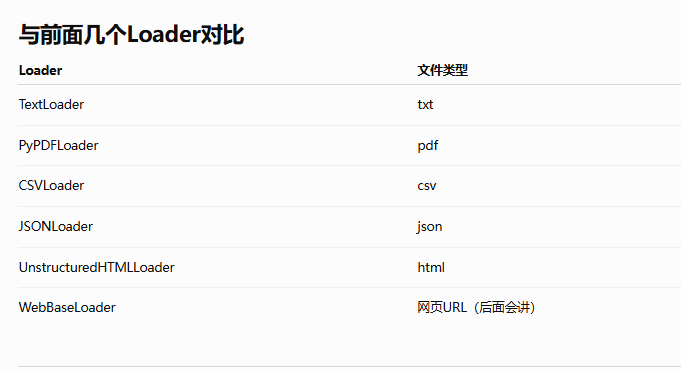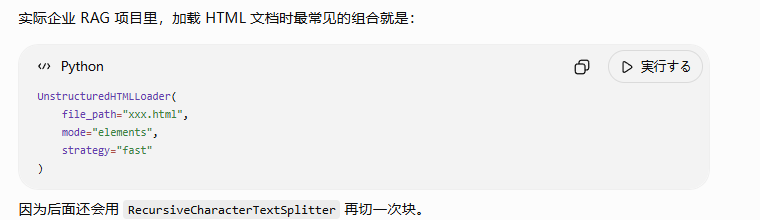

# 6、加载markdown文档

In [17]:
# 1.导入相关的依赖
from langchain.document_loaders import UnstructuredMarkdownLoader
from pprint import pprint

# 2.定义UnstructuredMarkdownLoader对象
md_loader = UnstructuredMarkdownLoader(
    file_path="asset/load/06-load.md",
    strategy="fast"
)

# 3.加载
docs = md_loader.load()

print(len(docs))
# 4.打印
for doc in docs:
    pprint(doc)

1
Document(page_content='# 自然语言处理技术文档\n'
                      '\n'
                      '本文档用于测试`UnstructuredMarkdownLoader`的中文处理能力。\n'
                      '\n'
                      '## 第一章：简介\n'
                      '\n'
                      '自然语言处理(NLP)是人工智能的重要分支，主要技术包括：\n'
                      '\n'
                      '- 文本分类\n'
                      '- 命名实体识别\n'
                      '- 机器翻译\n'
                      '- 情感分析\n'
                      '- 问答系统\n'
                      '\n'
                      '## 第二章：关键技术\n'
                      '\n'
                      '### 2.1 预训练模型\n'
                      '\n'
                      '1. **BERT**：双向Transformer编码器\n'
                      '2. **GPT**：自回归语言模型  \n'
                      '3. **T5**：文本到文本转换框架\n'
                      '\n'
                      '### 2.2 代码示例\n'
                      '\n'
                      '```python\n'
                      'from transformers import pipeline\n'
                      '\n'

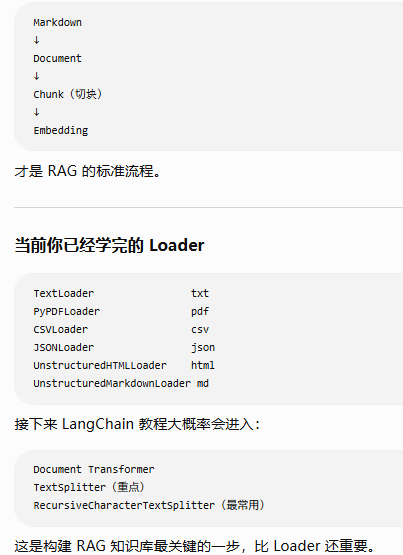

In [18]:
# 1.导入相关的依赖
from langchain.document_loaders import UnstructuredMarkdownLoader
from pprint import pprint

# 2.定义UnstructuredMarkdownLoader对象
md_loader = UnstructuredMarkdownLoader(
    file_path="asset/load/06-load.md",
    strategy="fast",
    mode="elements"
)

# 3.加载
docs = md_loader.load()

print(len(docs))
# 4.打印
for doc in docs:
    pprint(doc)

1
Document(page_content='# 自然语言处理技术文档\n'
                      '\n'
                      '本文档用于测试`UnstructuredMarkdownLoader`的中文处理能力。\n'
                      '\n'
                      '## 第一章：简介\n'
                      '\n'
                      '自然语言处理(NLP)是人工智能的重要分支，主要技术包括：\n'
                      '\n'
                      '- 文本分类\n'
                      '- 命名实体识别\n'
                      '- 机器翻译\n'
                      '- 情感分析\n'
                      '- 问答系统\n'
                      '\n'
                      '## 第二章：关键技术\n'
                      '\n'
                      '### 2.1 预训练模型\n'
                      '\n'
                      '1. **BERT**：双向Transformer编码器\n'
                      '2. **GPT**：自回归语言模型  \n'
                      '3. **T5**：文本到文本转换框架\n'
                      '\n'
                      '### 2.2 代码示例\n'
                      '\n'
                      '```python\n'
                      'from transformers import pipeline\n'
                      '\n'

# 7、加载指定的文件目录


In [19]:
# 1.导入相关的依赖
from langchain.document_loaders import DirectoryLoader
from langchain.document_loaders import PythonLoader
from pprint import pprint

# 2.定义DirectoryLoader对象,指定要加载的文件夹路径、要加载的文件类型和是否使用多线程
directory_loader = DirectoryLoader(
    path="./asset/load",
    glob="*.py",
    use_multithreading=True,
    show_progress=True,
    loader_cls=PythonLoader
)

# 3.加载
docs = directory_loader.load()

# 4.打印
print(len(docs))
for doc in docs:
    pprint(doc)

4
Document(page_content='"""\n'
                      '一 函数入门\n'
                      '"""\n'
                      '# 1.不使用函数\n'
                      '# 打印欢迎信息1\n'
                      'print("********************************")\n'
                      'print("*                              *")\n'
                      'print("*     欢迎来到Python世界       *")\n'
                      'print("*                              *")\n'
                      'print("********************************")\n'
                      '\n'
                      '# 打印欢迎信息2\n'
                      'print("********************************")\n'
                      'print("*                              *")\n'
                      'print("*     欢迎来到Python世界       *")\n'
                      'print("*                              *")\n'
                      'print("********************************")\n'
                      '\n'
                      '# 打印欢迎信息3\n'
                      'print("*********

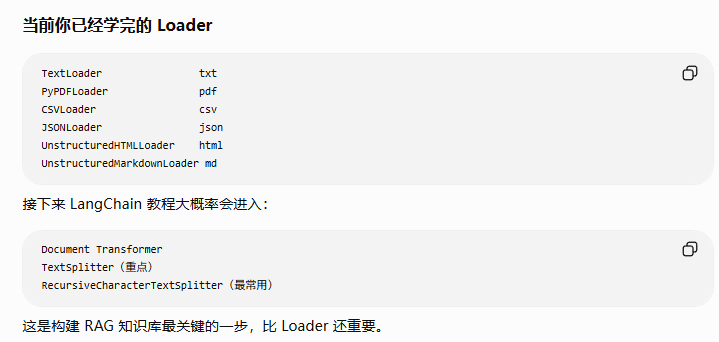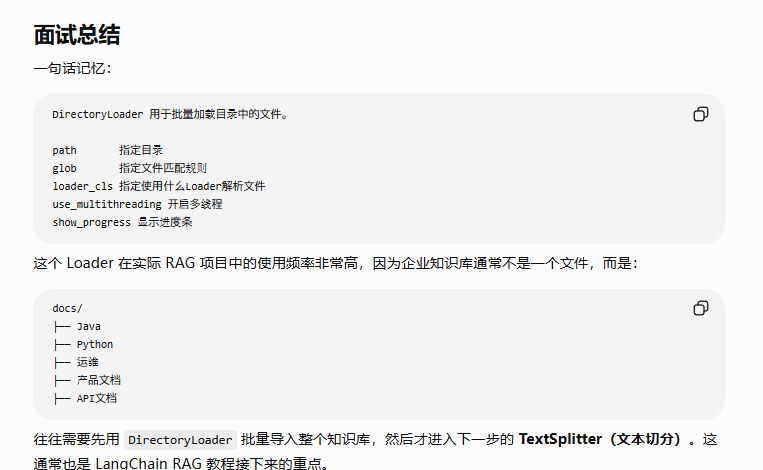